## Check GPU

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Import Libraries


In [2]:
import os
import time
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from pathlib import Path
from collections import Counter, defaultdict

from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

These tools help us get data ready, build models, train them, see how well they work and show the results.

## Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Set Dataset path

In [4]:
train_dir = Path("/content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/train")
test_dir = Path("/content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/test")

print("Train directory available: ", train_dir.exists())
print("Test directory available: ", test_dir.exists())
print("Train path: ", train_dir)
print("Test path: ", test_dir)

Train directory available:  True
Test directory available:  True
Train path:  /content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/train
Test path:  /content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/test


## Understand dataset structure

In [5]:
train_counts = {}
test_counts = {}

for class_name in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_name
    if class_path.is_dir():
        train_counts[class_name] = len(list(class_path.glob("*.jpg")))

for class_name in sorted(os.listdir(test_dir)):
    class_path = test_dir / class_name
    if class_path.is_dir():
        test_counts[class_name] = len(list(class_path.glob("*.jpg")))

print("Image counts for training dataset:")
print(train_counts)

print("\nImage counts for testing dataset:")
print(test_counts)

print("\nTotal images in training set:", sum(train_counts.values()))
print("Total images in test set:", sum(test_counts.values()))
print("Total number of categories:", len(train_counts))


Image counts for training dataset:
{'buildings': 2184, 'forest': 2264, 'glacier': 2397, 'mountain': 2505, 'sea': 2267, 'street': 2375}

Image counts for testing dataset:
{'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}

Total images in training set: 13992
Total images in test set: 3000
Total number of categories: 6


## Plot Class Distribution

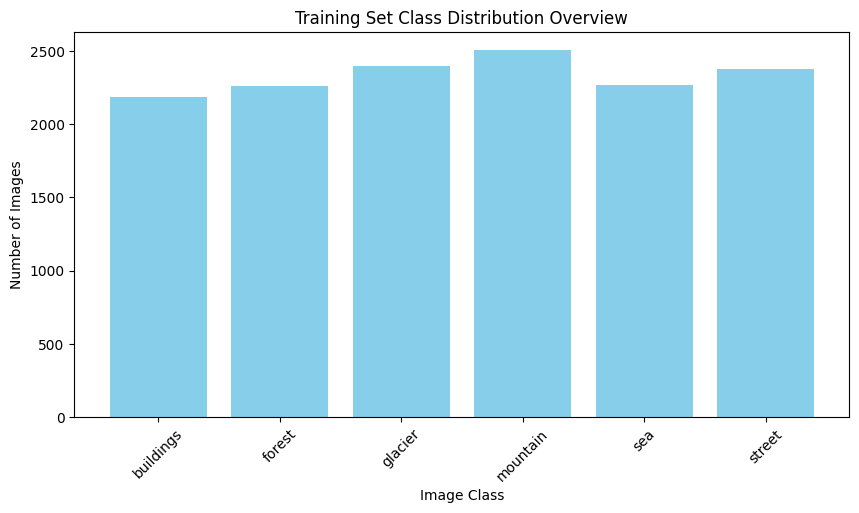

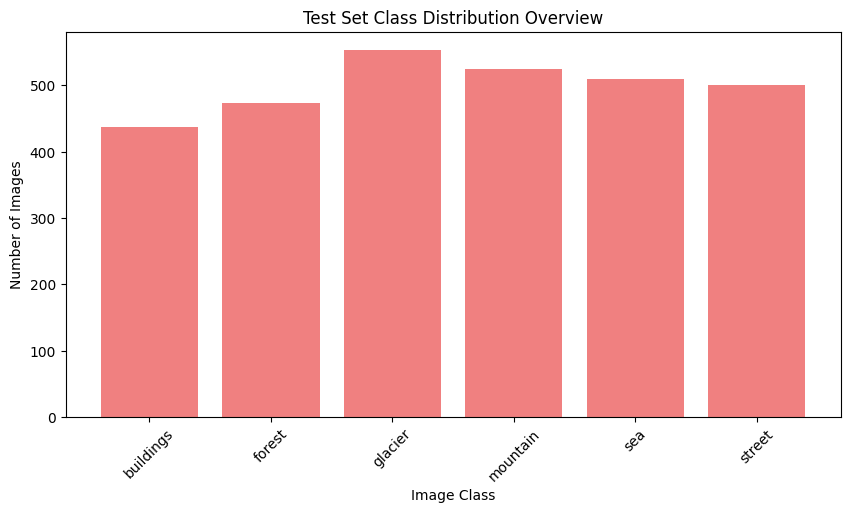

In [6]:
plt.figure(figsize=(10,5))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.title("Training Set Class Distribution Overview")
plt.xlabel("Image Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(test_counts.keys(), test_counts.values(), color='lightcoral')
plt.title("Test Set Class Distribution Overview")
plt.xlabel("Image Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

This picture is great for reports.

## Showing sample image from each class

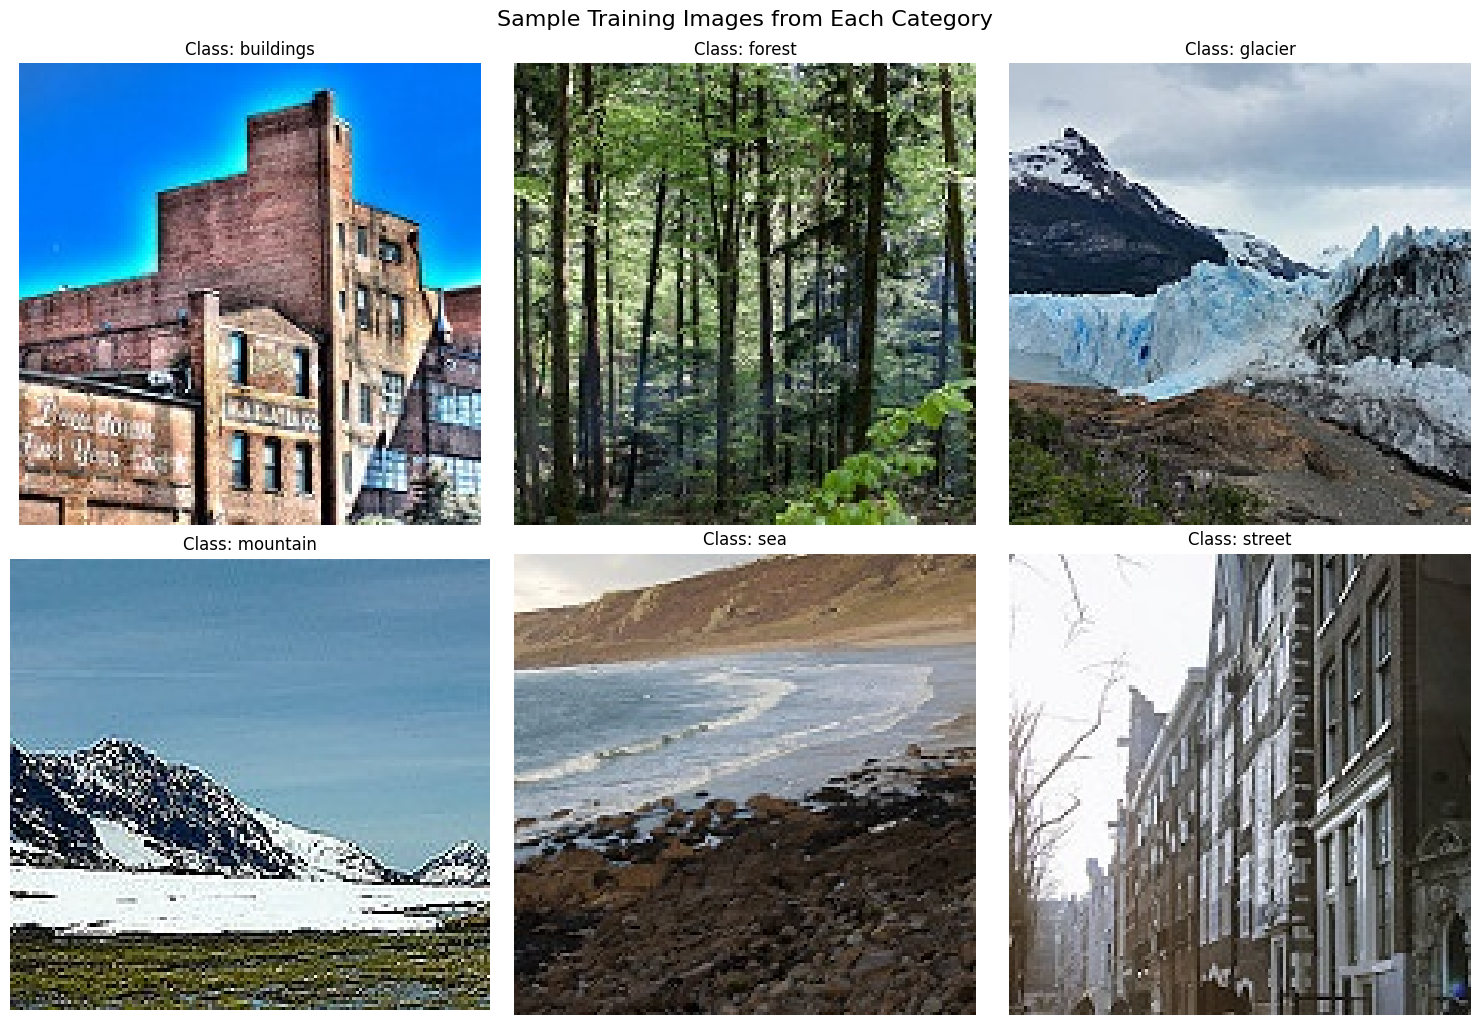

In [7]:
class_names = sorted(train_counts.keys())

plt.figure(figsize=(15,10))

for i, class_name in enumerate(class_names):
    class_path = train_dir / class_name
    img_path = random.choice(list(class_path.glob("*.jpg")))
    img = plt.imread(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Training Images from Each Category", fontsize=16, y=1.02)
plt.show()

This shows what the images in each group actually look like.

## Checking for corrupted/bad files in both train and test

In [8]:
from PIL import Image
import os

def find_invalid_images(directory):
    bad_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.load()
            except Exception as e:
                bad_files.append((file_path, str(e)))

    return bad_files

In [9]:
bad_train = find_invalid_images(train_dir)
bad_test = find_invalid_images(test_dir)

print("Invalid images in TRAIN:", len(bad_train))
for f, err in bad_train[:20]:
    print(f, " = ", err)

print("\nInvalid images in TEST:", len(bad_test))
for f, err in bad_test[:20]:
    print(f, " = ", err)

Invalid images in TRAIN: 0

Invalid images in TEST: 0


## Checking for Imbalance classes in datasets

In [10]:
import os

# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        class_counts[class_name] = len(images)  # Count images in each class

# Print Class Balance
print("\nDistribution of image classes:")
print("=" * 45)
print(f"{'Category Name':<25}{'Image Count':>20}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>20}")

print("=" * 45)



Distribution of image classes:
Category Name                     Image Count
buildings                                2184
forest                                   2264
glacier                                  2397
mountain                                 2505
sea                                      2267
street                                   2375


## Create train, validation and test datasets

We have separate folders for training and testing data. Now, we will divide the training folder's images into 80% for training and 20% for validation.

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Image Categories:", class_names)
print("Total number of categories:", num_classes)


Found 13992 files belonging to 6 classes.
Using 11194 files for training.
Found 13992 files belonging to 6 classes.
Using 2798 files for validation.
Found 3000 files belonging to 6 classes.
Image Categories: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total number of categories: 6


## Normalize image and optimize pipeline

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

Pixels normally go from 0 to 255. Normalizing changes them to 0 to 1 which helps the model learn better.

## Data augmentation

In [13]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Visualize augmented images

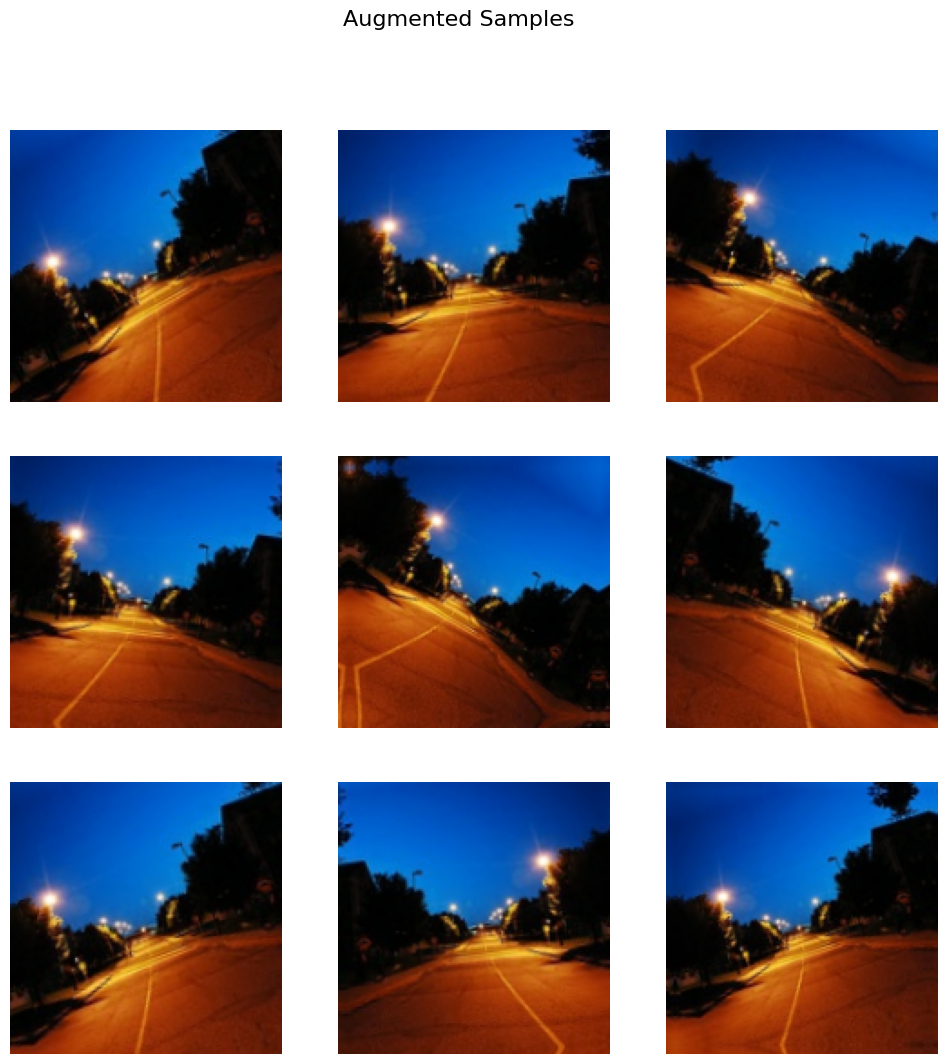

In [14]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0])
        plt.axis("off")
    plt.suptitle("Augmented Samples", fontsize=16)
    plt.show()

This shows how we made more diverse images.

# Baseline CNN from scratch

## Building baseline CNN

Our first basic model has:
1. 3 layers that find patterns.
2. Each of these is followed by a layer that shrinks the image.
3. 3 layers that learn complex connections.
4. A final layer to decide the image type.

In [15]:
baseline_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

## Compile baseline model

In [16]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

1. We use `sparse_categorical_crossentropy` because our categories are numbers.
2. We check how well the model works using accuracy, precision and recall.

## Train baseline model

In [17]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)
0
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping, reduce_lr]
)

baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 69s 170ms/step - accuracy: 0.5590 - loss: 1.1054 - val_accuracy: 0.6512 - val_loss: 0.9679 - learning_rate: 0.0010
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6801 - loss: 0.8544 - val_accuracy: 0.6973 - val_loss: 0.8656 - learning_rate: 0.0010
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7311 - loss: 0.7390 - val_accuracy: 0.7194 - val_loss: 0.7751 - learning_rate: 0.0010
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7552 - loss: 0.6753 - val_accuracy: 0.7698 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 5/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7793 - loss: 0.6154 - val_accuracy: 0.7781 - val_loss: 0.6703 - learning_rate: 0.0010
Epoch 6/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7937 - loss: 0.5827 - val_accuracy: 0.7959 - val_loss: 0.5876 - learning_rate: 0.0010
Epoch 7/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8055 - 

1. `EarlyStopping` stops training if the model isn't getting better, saving time and preventing it from memorizing too much.
2. `ReduceLROnPlateau` slowly lowers the learning rate if the model's improvement slows down.

## Plotting training curves

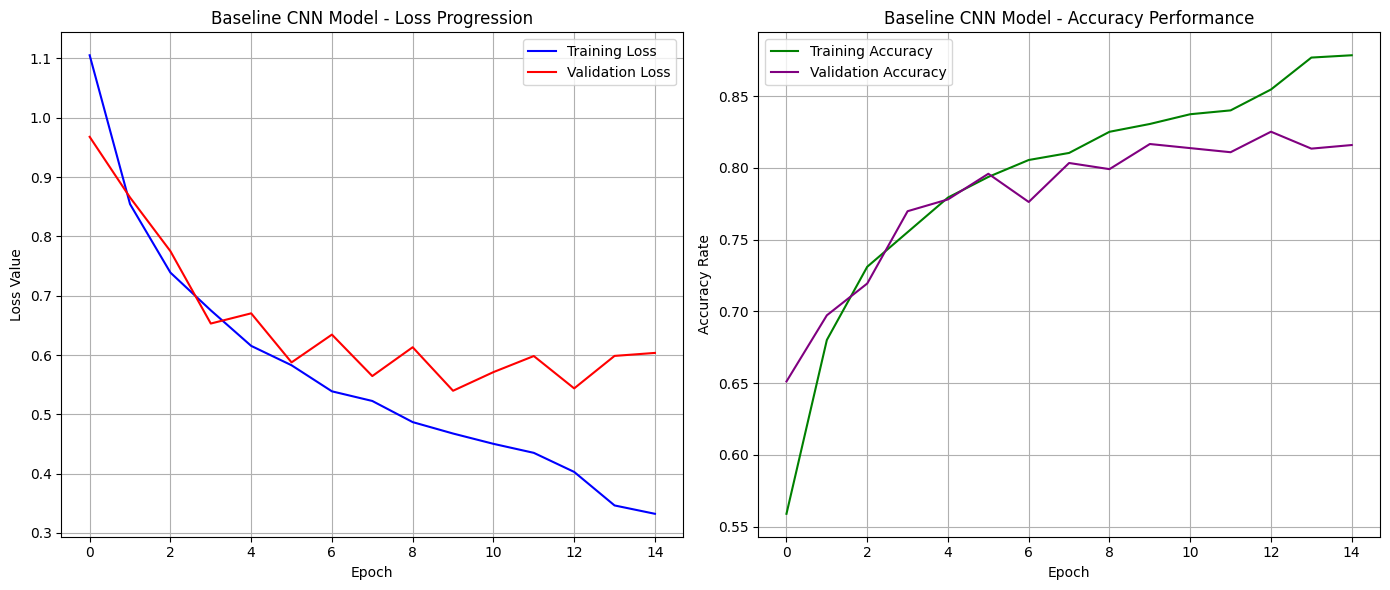

In [18]:
def plot_history(history, title):
    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.title(f'{title} - Loss Progression')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
    plt.title(f'{title} - Accuracy Performance')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy Rate')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN Model")

## Evaluate baseline model

In [19]:
baseline_results = baseline_model.evaluate(test_ds, verbose=1)
print("Baseline test results:", baseline_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.8053 - loss: 0.5552
Baseline test results: [0.55515056848526, 0.8053333163261414]


## Classification report and confusion matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

   buildings       0.70      0.88      0.78       437
      forest       0.94      0.96      0.95       474
     glacier       0.78      0.73      0.76       553
    mountain       0.79      0.72      0.75       525
         sea       0.77      0.77      0.77       510
      street       0.88      0.80      0.84       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



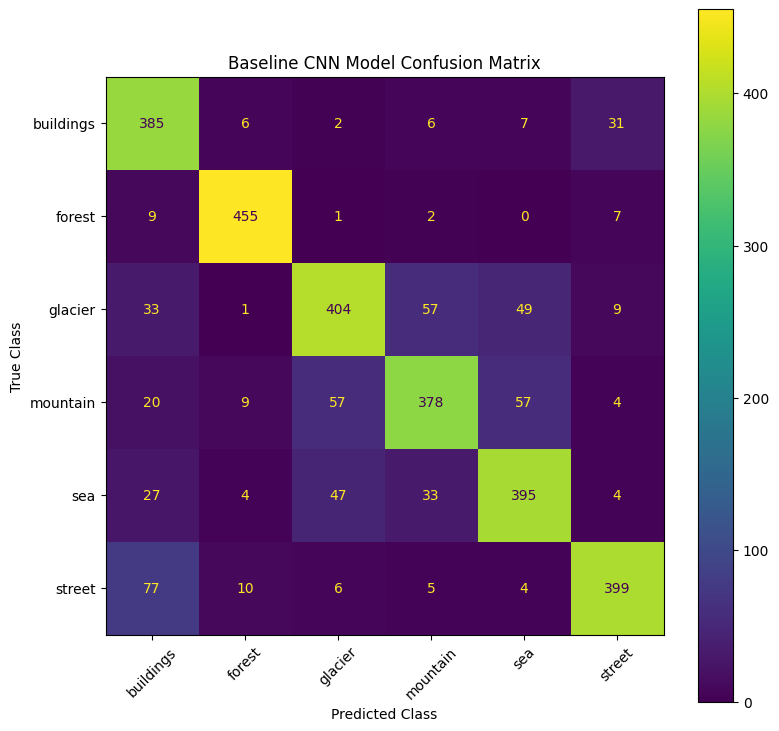

In [20]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)
plt.title("Baseline CNN Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

This tells us the F1 score, confusion matrix and precision which are ways to measure how good the model is.

## Oredict on sample test image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


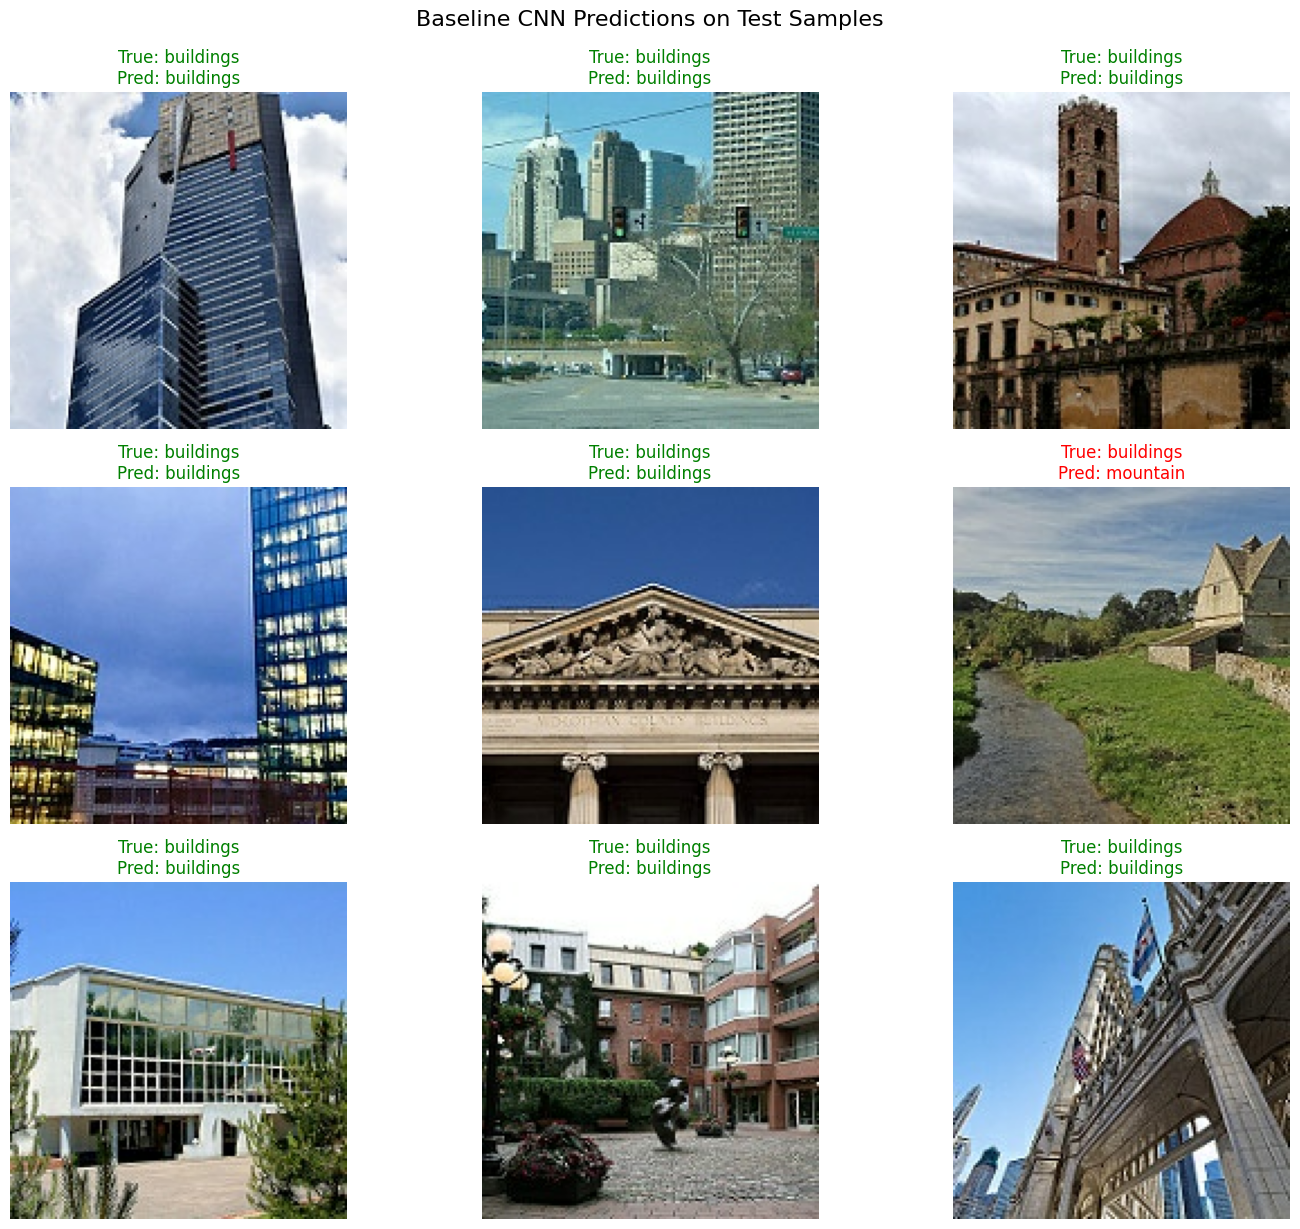

In [21]:
for images, labels in test_ds.take(1):
    preds = baseline_model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(15,12))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", color='green' if true_label == pred_label else 'red')
        plt.axis("off")
    plt.tight_layout()
    plt.suptitle("Baseline CNN Predictions on Test Samples", fontsize=16, y=1.02)
    plt.show()

# Deeper CNN with regularization

This model is designed to be bigger and better than the first, with more layers and special tricks like Batch Normalization and Dropout to help it learn well without getting confused.

## Building deepee CNN

In [22]:
def build_deeper_model(dropout_rate=0.5, optimizer='adam'):
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deeper_model_adam = build_deeper_model(dropout_rate=0.5, optimizer='adam')
deeper_model_adam.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 10,946,534 (41.76 MB)

 Trainable params: 10,946,086 (41.76 MB)

 Non-trainable params: 448 (1.75 KB)

This bigger model has extra layers to stop it from just memorizing the training data, so it can work well on new pictures.

## Train deeper model with Adam

In [23]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [24]:
start_time = time.time()

history_deeper_adam = deeper_model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping, reduce_lr]
)

deeper_adam_train_time = time.time() - start_time
print(f"Deeper model (Adam) training time: {deeper_adam_train_time:.2f} seconds")

Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 141ms/step - accuracy: 0.2416 - loss: 2.3142 - val_accuracy: 0.2141 - val_loss: 1.7654 - learning_rate: 0.0010
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.2684 - loss: 1.6475 - val_accuracy: 0.3410 - val_loss: 1.5072 - learning_rate: 0.0010
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.2732 - loss: 1.6334 - val_accuracy: 0.2934 - val_loss: 1.7909 - learning_rate: 0.0010
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.2949 - loss: 1.5816 - val_accuracy: 0.3531 - val_loss: 1.4964 - learning_rate: 0.0010
Epoch 5/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.3306 - loss: 1.5066 - val_accuracy: 0.4196 - val_loss: 1.4065 - learning_rate: 0.0010
Epoch 6/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.3568 - loss: 1.4637 - val_accuracy: 0.4307 - val_loss: 1.3296 - learning_rate: 0.0010
Epoch 7/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.3

## Plotting deeper model history

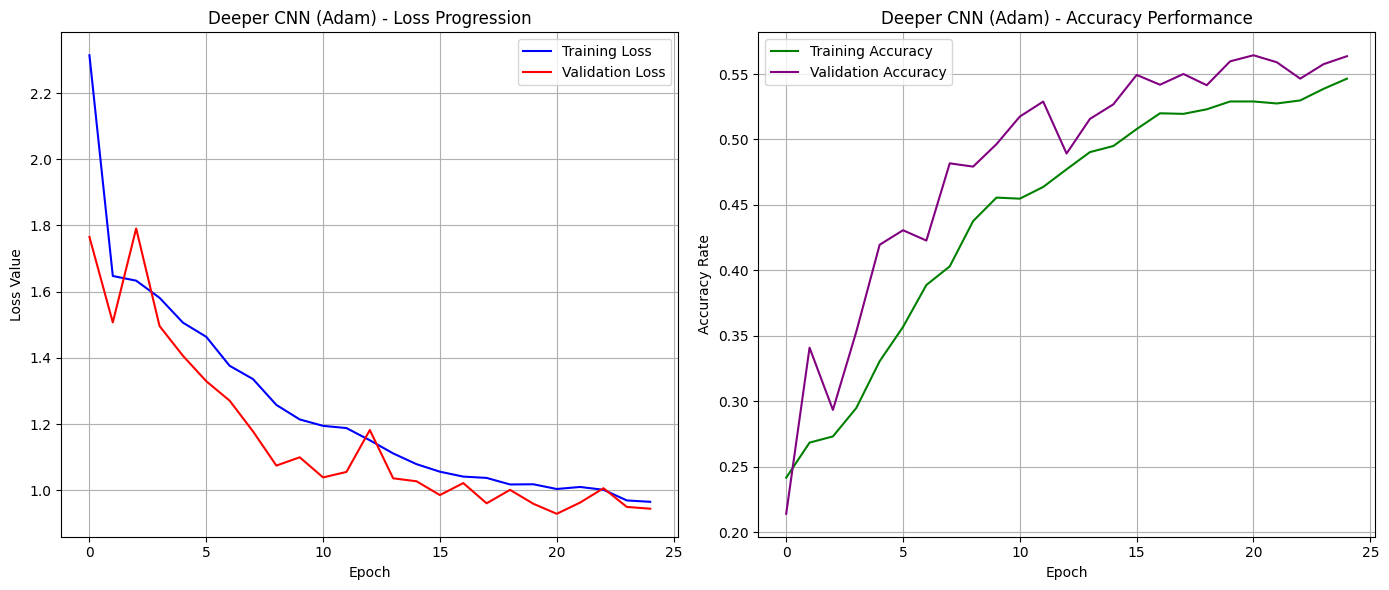

In [25]:
plot_history(history_deeper_adam, "Deeper CNN (Adam)")

## Evaluate deeper model with Adam

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5743 - loss: 0.9346
Deeper CNN (Adam) test results: [0.93459153175354, 0.5743333101272583]
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
              precision    recall  f1-score   support

   buildings       0.58      0.81      0.67       437
      forest       0.93      0.94      0.94       474
     glacier       0.36      0.75      0.49       553
    mountain       0.41      0.21      0.28       525
         sea       0.00      0.00      0.00       510
      street       0.82      0.79      0.80       501

    accuracy                           0.57      3000
   macro avg       0.52      0.58      0.53      3000
weighted avg       0.51      0.57      0.52      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


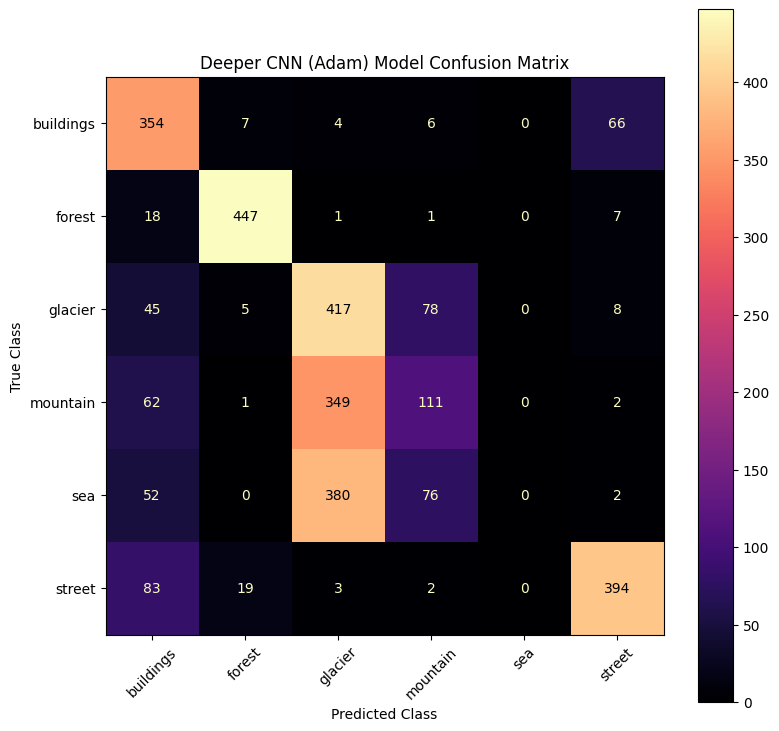

In [26]:
deeper_adam_results = deeper_model_adam.evaluate(test_ds, verbose=1)
print("Deeper CNN (Adam) test results:", deeper_adam_results)

y_pred_probs_deeper = deeper_model_adam.predict(test_ds)
y_pred_deeper = np.argmax(y_pred_probs_deeper, axis=1)

print(classification_report(y_true, y_pred_deeper, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_deeper)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='magma', xticks_rotation=45)
plt.title("Deeper CNN (Adam) Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Optimizer comparison SGD vs Adam

## Train deeper model with SGD

In [27]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

In [28]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

start_time = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping, reduce_lr]
)

deeper_sgd_train_time = time.time() - start_time
print(f"Deeper model (SGD) training time: {deeper_sgd_train_time:.2f} seconds")

Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 47s 127ms/step - accuracy: 0.3146 - loss: 1.7869 - val_accuracy: 0.2684 - val_loss: 1.6597 - learning_rate: 0.0100
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4002 - loss: 1.4223
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.4248 - loss: 1.3726 - val_accuracy: 0.4761 - val_loss: 1.2563 - learning_rate: 0.0100
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.4877 - loss: 1.1995 - val_accuracy: 0.5747 - val_loss: 1.1473 - learning_rate: 0.0050
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5207 - loss: 1.1597
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.5322 - loss: 1.1424 - val_accuracy: 0.5640 - val_loss: 1.1281 - learning_rate: 0.0050
Epoch 5/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.5605 -

## Evaluate SGD model

In [29]:
deeper_sgd_results = deeper_model_sgd.evaluate(test_ds, verbose=1)
print("Deeper CNN (SGD) test results:", deeper_sgd_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2490 - loss: 1.6653
Deeper CNN (SGD) test results: [1.6653258800506592, 0.24899999797344208]


# Ablation study

This is when we remove one part (like dropout) to see how much it helps the model's performance.

## Train model without dropout

In [30]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')


In [31]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')

start_time = time.time()

history_ablation = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping, reduce_lr]
)

ablation_train_time = time.time() - start_time
print(f"Ablation model training time: {ablation_train_time:.2f} seconds")

Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - accuracy: 0.5168 - loss: 1.5440 - val_accuracy: 0.2627 - val_loss: 2.7559 - learning_rate: 0.0010
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6172 - loss: 0.9813
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.6244 - loss: 0.9741 - val_accuracy: 0.5836 - val_loss: 1.1284 - learning_rate: 0.0010
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 130ms/step - accuracy: 0.6941 - loss: 0.8123 - val_accuracy: 0.7180 - val_loss: 0.7732 - learning_rate: 5.0000e-04
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.7419 - loss: 0.7037 - val_accuracy: 0.7691 - val_loss: 0.6483 - learning_rate: 5.0000e-04
Epoch 5/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.7636 - loss: 0.6357 - val_accuracy: 0.7638 - val_loss: 0.6618 - learning_rate: 5.0000e-04
Epoch 6/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - acc

## Evaluate ablation model

In [32]:
ablation_results = ablation_model.evaluate(test_ds, verbose=1)
print("Ablation model test results:", ablation_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8327 - loss: 0.5171
Ablation model test results: [0.517108678817749, 0.8326666951179504]


# Part B Transfer learning

Here, we'll compare models that learned from scratch with models that got a head start from others.

MobileNetV2 is a good choice for our pictures because:
1. It is smaller and faster than some other big models.
2. It is really good at understanding natural scenes.
3. It is easy to adjust it for our task in Colab.

## Reload datasets for MobileNetV2 input size

In [33]:
IMG_SIZE_TL = (224, 224)

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE
)

test_ds_tl = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 13992 files belonging to 6 classes.
Using 11194 files for training.
Found 13992 files belonging to 6 classes.
Using 2798 files for validation.
Found 3000 files belonging to 6 classes.


## Preprocess for MobileNetV2

In [34]:
# from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

# train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y))
# val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y))
# test_ds_tl = test_ds_tl.map(lambda x, y: (preprocess_input(x), y))

In [35]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

## Build transfer learning model

In [36]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

This is like teaching the model to see shapes and textures:
1. We freeze the main 'seeing' part of the pre-trained model.
2. We only train the new part that makes the final decision.

## Train transfer learning model

In [37]:
start_time = time.time()

history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=[early_stopping, reduce_lr]
)

transfer_train_time = time.time() - start_time
print(f"Transfer learning training time: {transfer_train_time:.2f} seconds")

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 132s 289ms/step - accuracy: 0.6773 - loss: 0.8274 - val_accuracy: 0.7731 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accuracy: 0.7525 - loss: 0.6566 - val_accuracy: 0.7856 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.7654 - loss: 0.6193 - val_accuracy: 0.7766 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.7785 - loss: 0.5876 - val_accuracy: 0.7920 - val_loss: 0.5510 - learning_rate: 0.0010
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.7826 - loss: 0.5713 - val_accuracy: 0.7916 - val_loss: 0.5557 - learning_rate: 0.0010
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.7861 - loss: 0.5557 - val_accuracy: 0.7920 - val_loss: 0.5464 - learning_rate: 0.0010
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.

## Fine tune the pre-trained model

In [38]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_finetune = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=[early_stopping, reduce_lr]
)

finetune_train_time = time.time() - start_time
print(f"Fine-tuning training time: {finetune_train_time:.2f} seconds")

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 116s 265ms/step - accuracy: 0.6014 - loss: 1.2347 - val_accuracy: 0.7713 - val_loss: 0.7022 - learning_rate: 1.0000e-05
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7110 - loss: 0.8040
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 69s 197ms/step - accuracy: 0.7212 - loss: 0.7628 - val_accuracy: 0.7759 - val_loss: 0.6892 - learning_rate: 1.0000e-05
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.7524 - loss: 0.6554 - val_accuracy: 0.7759 - val_loss: 0.6633 - learning_rate: 5.0000e-06
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7685 - loss: 0.6145
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 187ms/step - accuracy: 0.7709 - loss: 0.5988 - val_accuracy: 0.7759 - val_loss: 0.6414 - learning_rate: 5.0000e-06
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 64s 182ms/step - 

This is like giving the pre-trained model a 'gentle refresher':
1. We first trained the new decision-making layers.
2. Then, we 'unlocked' some of the pre-trained layers.
3. We used a very, very small learning rate so it just slightly adjusts its knowledge, without forgetting what it already learned.

In [39]:
from sklearn.metrics import classification_report

y_true_tl = np.concatenate([y for x, y in test_ds_tl], axis=0)
y_pred_probs_tl = transfer_model.predict(test_ds_tl)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 368ms/step
              precision    recall  f1-score   support

   buildings       0.86      0.67      0.75       437
      forest       0.89      0.98      0.93       474
     glacier       0.73      0.68      0.70       553
    mountain       0.65      0.69      0.67       525
         sea       0.61      0.77      0.68       510
      street       0.88      0.74      0.80       501

    accuracy                           0.75      3000
   macro avg       0.77      0.75      0.76      3000
weighted avg       0.76      0.75      0.75      3000



## Evaluate transfer learning model

In [40]:
transfer_results = transfer_model.evaluate(test_ds_tl, verbose=1)
print("Transfer learning / fine-tuned model test results:", transfer_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 319ms/step - accuracy: 0.7517 - loss: 0.7406
Transfer learning / fine-tuned model test results: [0.7405511140823364, 0.7516666650772095]


## Compare all models

In [41]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN (Adam)",
        "Deeper CNN (SGD)",
        "Ablation (No Dropout)",
        "Transfer Learning"
    ],
    "Test Loss": [
        baseline_results[0],
        deeper_adam_results[0],
        deeper_sgd_results[0],
        ablation_results[0],
        transfer_results[0]
    ],
    "Test Accuracy": [
        baseline_results[1],
        deeper_adam_results[1],
        deeper_sgd_results[1],
        ablation_results[1],
        transfer_results[1]
    ],
    "Training Time (sec)": [
        baseline_train_time,
        deeper_adam_train_time,
        deeper_sgd_train_time,
        ablation_train_time,
        transfer_train_time + finetune_train_time
    ]
})

results_df = results_df.round(4)
results_df

,Model,Test Loss,Test Accuracy,Training Time (sec)
0,Baseline CNN,0.5552,0.8053,235.1672
1,Deeper CNN (Adam),0.9346,0.5743,1129.2327
2,Deeper CNN (SGD),1.6653,0.2490,309.3253
3,Ablation (No Dropout),0.5171,0.8327,943.5955
4,Transfer Learning,0.7406,0.7517,1353.3542


## Plot comparison

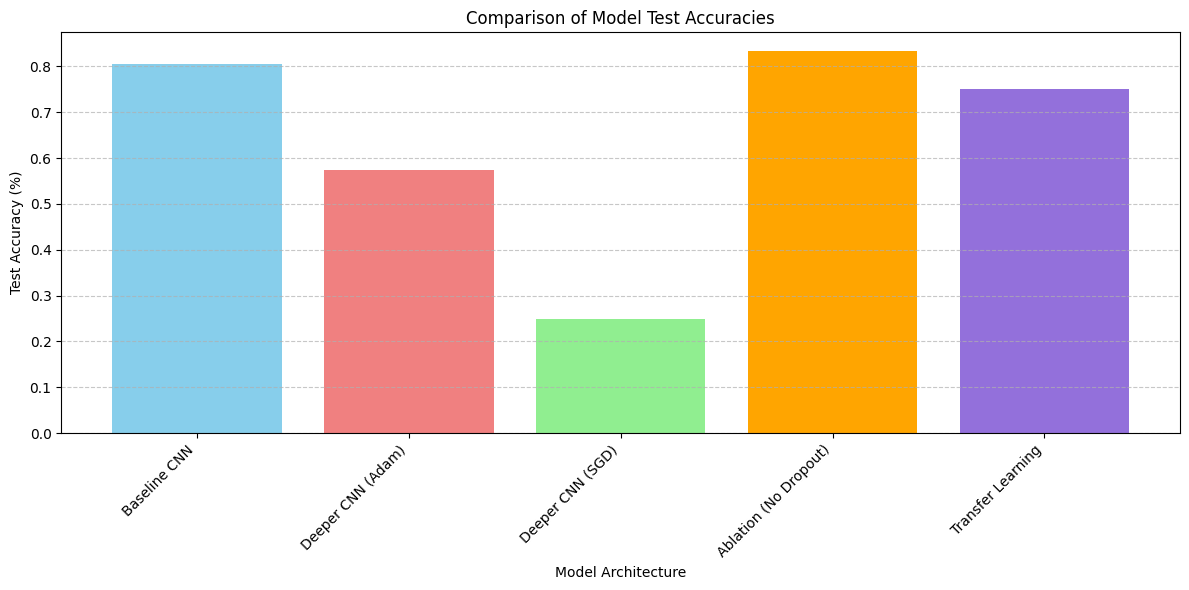

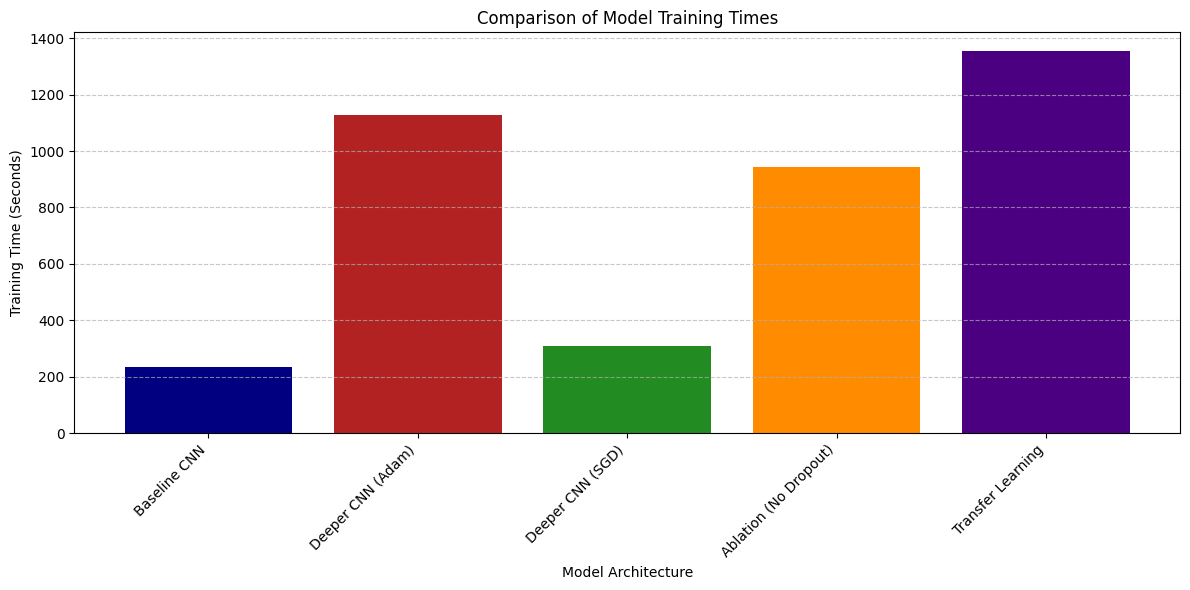

In [42]:
plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["Test Accuracy"], color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'mediumpurple'])
plt.title("Comparison of Model Test Accuracies")
plt.xlabel("Model Architecture")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["Training Time (sec)"], color=['navy', 'firebrick', 'forestgreen', 'darkorange', 'indigo'])
plt.title("Comparison of Model Training Times")
plt.xlabel("Model Architecture")
plt.ylabel("Training Time (Seconds)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()